# Лабораторная работа №3 — моделирование, эксперименты и анализ ошибок


1. **Классификация документов** на `rvl-cdip-small-200`.
2. **Распознавание текста (OCR)** на `FUNSD`.


Для OCR в качестве baseline используется **Tesseract**, а финальная улучшенная модель — **TrOCR fine-tuned на FUNSD**.

In [1]:
%pip install numpy pandas pillow tqdm matplotlib scikit-learn transformers pytesseract ipython
%pip install torch torchvision torchaudio torchmetrics --index-url https://download.pytorch.org/whl/cu118

     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     -------------------- ----------------- 30.7/57.7 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 57.7/57.7 kB 765.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 52.8/52.8 kB 2.7 MB/s eta 0:00:00
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     ----------------------------------- -- 112.6/119.8 kB 3.2 MB/s eta 0:00:01
     -------------------------------------- 119.8/119.8 kB 3.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 3.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ---------------------------------------- 41.5/41.5 kB ? eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -----------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp311-cp311-win_amd64.whl.metadata (27 kB)
  Using cached https://download-r2.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download-r2.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp311-cp311-win_amd64.whl.metadata (6.8 kB)
     ---------------------------------------- 0.0/731.6 kB ? eta -:--:--
     -------------------- ----------------- 389.1/731.6 kB 8.1 MB/s eta 0:00:01
     -------------------------------------- 731.6/731.6 kB 9.2 MB/s eta 0:00:00
Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp311-cp311-win_amd64.whl (2817.2 MB)
Using cached https://download-r2.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp311-cp311-win_amd64.whl (5.5 MB)
Using cached https://download-r2.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp311-cp311-win_amd64.whl (4.1


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image, ImageFile, ImageOps
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from transformers import TrOCRProcessor, VisionEncoderDecoderModel

import pytesseract

ImageFile.LOAD_TRUNCATED_IMAGES = True

c:\Users\OutHelix\Desktop\final-train-test\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
@dataclass
class Config:
    # Paths
    rvl_cdip_root: str = "datasets/rvl-cdip-small-200"
    funsd_root: str = "datasets/FUNSD"
    output_dir: str = "outputs"

    # Classification
    classifier_img_size: int = 224
    classifier_batch_size: int = 16 if torch.cuda.is_available() else 8
    classifier_epochs_frozen: int = 10
    classifier_epochs_finetune: int = 10
    classifier_lr_head: float = 3e-4
    classifier_lr_finetune: float = 1e-4
    val_size: float = 0.1
    test_size: float = 0.2

    # OCR
    ocr_model_name: str = "microsoft/trocr-base-printed"
    ocr_batch_size: int = 2 if torch.cuda.is_available() else 1
    ocr_epochs: int = 5
    ocr_lr: float = 1e-5
    ocr_max_target_length: int = 32
    ocr_num_beams: int = 1
    ocr_crop_pad: int = 2
    ocr_max_train_samples: int = 2000
    ocr_min_word_len: int = 1
    freeze_ocr_encoder: bool = True
    grad_accum_steps: int = 2 if torch.cuda.is_available() else 1

    # Page-level inference
    ocr_page_lang: str = "eng"
    ocr_page_min_conf: int = 40
    ocr_page_min_box_size: int = 8
    ocr_page_max_words: int = 500
    ocr_page_pad: int = 4
    ocr_page_batch_size: int = 8

config = Config()
Path(config.output_dir).mkdir(parents=True, exist_ok=True)
print(config)


Config(rvl_cdip_root='datasets/rvl-cdip-small-200', funsd_root='datasets/FUNSD', output_dir='outputs', classifier_img_size=224, classifier_batch_size=16, classifier_epochs_frozen=10, classifier_epochs_finetune=10, classifier_lr_head=0.0003, classifier_lr_finetune=0.0001, val_size=0.1, test_size=0.2, ocr_model_name='microsoft/trocr-base-printed', ocr_batch_size=2, ocr_epochs=5, ocr_lr=1e-05, ocr_max_target_length=32, ocr_num_beams=1, ocr_crop_pad=2, ocr_max_train_samples=2000, ocr_min_word_len=1, freeze_ocr_encoder=True, grad_accum_steps=2, ocr_page_lang='eng', ocr_page_min_conf=40, ocr_page_min_box_size=8, ocr_page_max_words=500, ocr_page_pad=4, ocr_page_batch_size=8)


## Вспомогательные функции

In [5]:

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

plt.style.use("seaborn-v0_8-whitegrid")

def ensure_image(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in IMG_EXTS

def safe_open_image(path: Path) -> Image.Image:
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)
    return img.convert("RGB")

def normalize_text(text: str) -> str:
    text = text or ""
    text = text.replace("\n", " ").replace("\r", " ")
    text = " ".join(text.split())
    return text.strip()

def safe_stratify(labels: np.ndarray):
    labels = np.asarray(labels)
    if labels.size < 2:
        return None
    uniq, counts = np.unique(labels, return_counts=True)
    if len(uniq) < 2 or counts.min() < 2:
        return None
    return labels

def levenshtein_distance(seq1, seq2) -> int:
    if seq1 == seq2:
        return 0
    if len(seq1) < len(seq2):
        seq1, seq2 = seq2, seq1
    previous = list(range(len(seq2) + 1))
    for i, c1 in enumerate(seq1, start=1):
        current = [i]
        for j, c2 in enumerate(seq2, start=1):
            insertions = previous[j] + 1
            deletions = current[j - 1] + 1
            substitutions = previous[j - 1] + (c1 != c2)
            current.append(min(insertions, deletions, substitutions))
        previous = current
    return previous[-1]

def compute_cer(pred: str, ref: str) -> float:
    ref = normalize_text(ref)
    pred = normalize_text(pred)
    if len(ref) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return levenshtein_distance(pred, ref) / max(1, len(ref))

def compute_wer(pred: str, ref: str) -> float:
    ref_words = normalize_text(ref).split()
    pred_words = normalize_text(pred).split()
    if len(ref_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0
    return levenshtein_distance(pred_words, ref_words) / max(1, len(ref_words))

def plot_history(
    df: pd.DataFrame,
    title: str,
    metrics: List[Tuple[str, str, str]],
    save_path: Optional[Path] = None,
):
    if df.empty:
        print(f"Нет истории для графика: {title}")
        return

    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(4.1 * n, 2.9), squeeze=False)
    axes = axes.flatten()

    for ax, (train_col, val_col, ylabel) in zip(axes, metrics):
        if train_col in df.columns:
            ax.plot(df["epoch"], df[train_col], marker="o", markersize=3, linewidth=2, label=train_col)
        if val_col is not None and val_col in df.columns:
            ax.plot(df["epoch"], df[val_col], marker="s", markersize=3, linewidth=2, label=val_col)

        ax.set_title(ylabel, fontsize=10)
        ax.set_xlabel("Epoch", fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False, fontsize=8)

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.05)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

def plot_comparison_bars(
    df: pd.DataFrame,
    title: str,
    metric_cols: List[str],
    save_path: Optional[Path] = None,
    invert_metrics: Optional[set] = None,
):
    if df.empty:
        return

    invert_metrics = invert_metrics or set()
    n = len(metric_cols)
    fig, axes = plt.subplots(1, n, figsize=(3.8 * n, 2.8), squeeze=False)
    axes = axes.flatten()

    for ax, metric in zip(axes, metric_cols):
        values = df[metric].values
        bars = ax.bar(df["Model"], values)
        if metric in invert_metrics:
            ax.invert_yaxis()
        ax.set_title(metric, fontsize=10)
        ax.tick_params(axis="x", labelrotation=15, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(True, axis="y", alpha=0.2)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"{value:.3f}",
                ha="center",
                va="bottom" if metric not in invert_metrics else "top",
                fontsize=8,
            )

    fig.suptitle(title, fontsize=13, y=1.05)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


In [6]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix", save_path=None):
    cm = confusion_matrix(y_true, y_pred, normalize='true')  # нормализация!
    cm = np.round(cm, 2)

    fig, ax = plt.subplots(figsize=(7, 5))

    im = ax.imshow(cm)

    ax.set_title(title, fontsize=12)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))

    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(class_names, fontsize=7)

    # значения в ячейках
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            val = cm[i, j]
            if val > 0:
                ax.text(j, i, val,
                        ha="center", va="center",
                        fontsize=6)

    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

## 1. Классификация документов на RVL-CDIP-small-200

In [ ]:
def collect_samples_from_folder(root: Path) -> Tuple[List[Tuple[str, int]], List[str], Dict[str, int]]:
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"Не найден каталог: {root}")

    class_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
    if not class_dirs:
        raise ValueError(f"В каталоге {root} не найдено папок-классов.")

    class_names = [p.name for p in class_dirs]
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    samples: List[Tuple[str, int]] = []
    for class_dir in class_dirs:
        for path in sorted(class_dir.rglob("*")):
            if ensure_image(path):
                samples.append((str(path), class_to_idx[class_dir.name]))

    if not samples:
        raise ValueError(f"В каталоге {root} не найдено изображений.")

    return samples, class_names, class_to_idx

def split_image_samples(
    samples: List[Tuple[str, int]],
    val_size: float = 0.1,
    test_size: float = 0.2,
    seed: int = 42,
):
    labels = np.array([s[1] for s in samples])
    idx = np.arange(len(samples))
    strat = safe_stratify(labels)

    train_idx, temp_idx = train_test_split(
        idx,
        test_size=val_size + test_size,
        random_state=seed,
        stratify=strat,
    )

    temp_labels = labels[temp_idx]
    rel_test = test_size / (val_size + test_size)
    strat_temp = safe_stratify(temp_labels)

    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=rel_test,
        random_state=seed,
        stratify=strat_temp,
    )

    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]
    test_samples = [samples[i] for i in test_idx]
    return train_samples, val_samples, test_samples

def split_train_val_samples(
    samples: List[Tuple[str, int]],
    val_size: float = 0.1,
    seed: int = 42,
):
    labels = np.array([s[1] for s in samples])
    strat = safe_stratify(labels)
    train_samples, val_samples = train_test_split(
        samples,
        test_size=val_size,
        random_state=seed,
        stratify=strat,
    )
    return list(train_samples), list(val_samples)

def load_rvl_cdip_splits(root_dir: str, seed: int = 42):
    root = Path(root_dir)
    train_dir = root / "train"
    val_dir = root / "val"
    test_dir = root / "test"

    if train_dir.exists():
        train_samples, class_names, _ = collect_samples_from_folder(train_dir)

        if test_dir.exists() and val_dir.exists():
            val_samples, _, _ = collect_samples_from_folder(val_dir)
            test_samples, _, _ = collect_samples_from_folder(test_dir)
        elif val_dir.exists():
            train_samples, val_samples = split_train_val_samples(
                train_samples,
                val_size=config.val_size,
                seed=seed,
            )
            test_samples, _, _ = collect_samples_from_folder(val_dir)
        else:
            train_samples, val_samples, test_samples = split_image_samples(
                train_samples,
                val_size=config.val_size,
                test_size=config.test_size,
                seed=seed,
            )

        return train_samples, val_samples, test_samples, class_names

    # Фоллбек: если данные лежат сразу в папке root по классам
    all_samples, class_names, _ = collect_samples_from_folder(root)
    train_samples, val_samples, test_samples = split_image_samples(
        all_samples,
        val_size=config.val_size,
        test_size=config.test_size,
        seed=seed,
    )
    return train_samples, val_samples, test_samples, class_names

class DocumentImageDataset(Dataset):
    def __init__(self, samples: List[Tuple[str, int]], transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = safe_open_image(Path(path))
        if self.transform is not None:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

train_transform = transforms.Compose([
    transforms.Resize((config.classifier_img_size, config.classifier_img_size)),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((config.classifier_img_size, config.classifier_img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def make_image_loaders(train_samples, val_samples, test_samples, batch_size=16):
    if len(train_samples) == 0 or len(val_samples) == 0 or len(test_samples) == 0:
        raise ValueError(
            f"Пустая выборка: train={len(train_samples)}, val={len(val_samples)}, test={len(test_samples)}"
        )

    train_ds = DocumentImageDataset(train_samples, transform=train_transform)
    val_ds = DocumentImageDataset(val_samples, transform=eval_transform)
    test_ds = DocumentImageDataset(test_samples, transform=eval_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

In [8]:
class DocumentClassifier(nn.Module):
    def __init__(self, num_classes: int, freeze_backbone: bool = True):
        super().__init__()
        backbone = torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone
        self.head = nn.Linear(in_features, num_classes)

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

def evaluate_classifier(model, loader):
    if len(loader) == 0:
        raise ValueError("Пустой DataLoader в evaluate_classifier.")

    model.eval()
    all_preds, all_targets = [], []
    losses = []
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)
            losses.append(loss.item())

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_targets.extend(labels.cpu().numpy().tolist())

    acc = accuracy_score(all_targets, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average="macro", zero_division=0
    )

    return {
        "loss": float(np.mean(losses)) if losses else 0.0,
        "accuracy": float(acc),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
    }

def train_classifier(
    model,
    train_loader,
    val_loader,
    epochs=5,
    lr=3e-4,
    save_dir: Optional[Path] = None,
    run_name: str = "classifier",
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    best_state = None
    best_f1 = -1.0
    best_epoch = 0
    history = []

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        best_path = save_dir / f"{run_name}_best.pt"
    else:
        best_path = None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = []

        for images, labels in tqdm(train_loader, desc=f"{run_name} epoch {epoch}/{epochs}"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss.append(loss.item())

        train_loss = float(np.mean(running_loss)) if running_loss else 0.0
        val_metrics = evaluate_classifier(model, val_loader)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        })

        print(
            f"{run_name} | epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            if best_path is not None:
                torch.save(best_state, best_path)

        scheduler.step()

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

Классы: 16
Train/Val/Test: 2304 / 256 / 640


classifier_frozen epoch 1/10: 100%|██████████| 144/144 [00:51<00:00,  2.77it/s]


classifier_frozen | epoch 1/10 | train_loss=2.6987 | val_acc=0.2266 | val_f1=0.2036


classifier_frozen epoch 2/10: 100%|██████████| 144/144 [00:29<00:00,  4.95it/s]


classifier_frozen | epoch 2/10 | train_loss=2.3798 | val_acc=0.3281 | val_f1=0.3140


...

classifier_frozen | epoch 8/10 | train_loss=1.8665 | val_acc=0.5000 | val_f1=0.4945


classifier_frozen epoch 9/10: 100%|██████████| 144/144 [00:31<00:00,  4.60it/s]


classifier_frozen | epoch 9/10 | train_loss=1.8704 | val_acc=0.4766 | val_f1=0.4720


classifier_frozen epoch 10/10: 100%|██████████| 144/144 [00:34<00:00,  4.17it/s]


classifier_frozen | epoch 10/10 | train_loss=1.8334 | val_acc=0.4883 | val_f1=0.4803


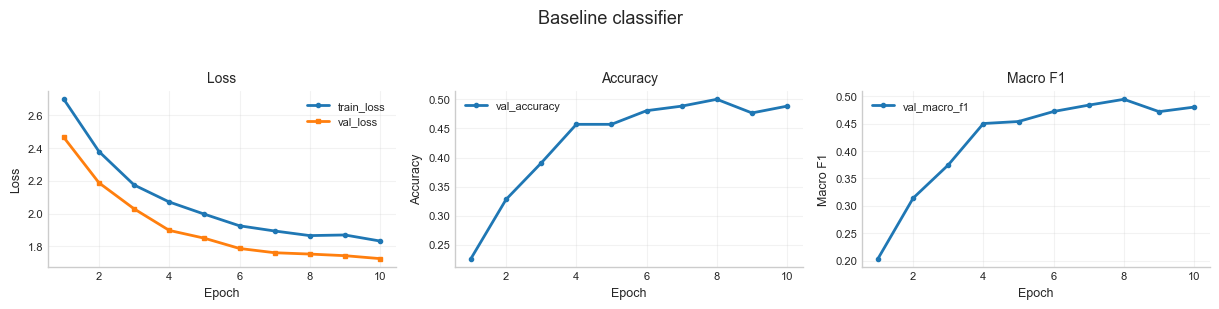

classifier_finetuned epoch 1/10: 100%|██████████| 144/144 [00:33<00:00,  4.24it/s]


classifier_finetuned | epoch 1/10 | train_loss=1.8096 | val_acc=0.6641 | val_f1=0.6531


classifier_finetuned epoch 2/10: 100%|██████████| 144/144 [00:32<00:00,  4.38it/s]


classifier_finetuned | epoch 2/10 | train_loss=1.0625 | val_acc=0.6914 | val_f1=0.7014


classifier_finetuned epoch 3/10: 100%|██████████| 144/144 [00:32<00:00,  4.41it/s]


...

classifier_finetuned | epoch 8/10 | train_loss=0.0667 | val_acc=0.7617 | val_f1=0.7611


classifier_finetuned epoch 9/10: 100%|██████████| 144/144 [00:32<00:00,  4.37it/s]


classifier_finetuned | epoch 9/10 | train_loss=0.0567 | val_acc=0.7578 | val_f1=0.7565


classifier_finetuned epoch 10/10: 100%|██████████| 144/144 [00:33<00:00,  4.30it/s]


classifier_finetuned | epoch 10/10 | train_loss=0.0559 | val_acc=0.7539 | val_f1=0.7534


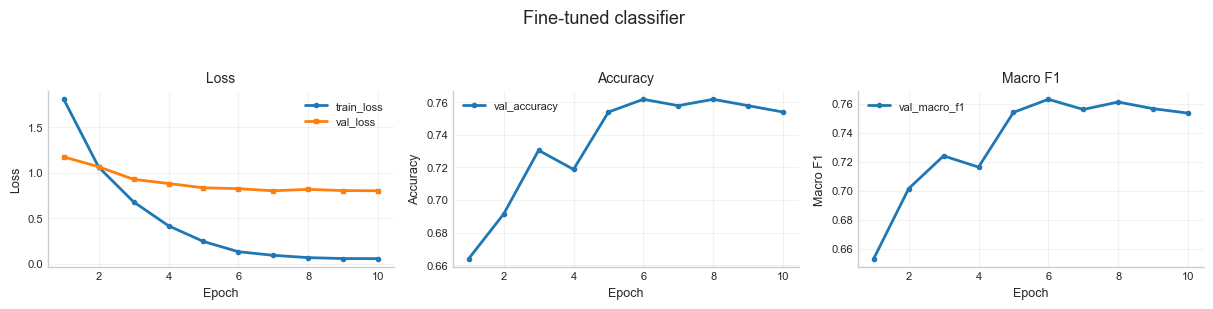

Baseline validation: {'loss': 1.7538234367966652, 'accuracy': 0.5, 'macro_precision': 0.5023000198116297, 'macro_recall': 0.5, 'macro_f1': 0.49454166054873927}
Baseline test: {'loss': 1.9310389265418053, 'accuracy': 0.4375, 'macro_precision': 0.4499322811884817, 'macro_recall': 0.4375, 'macro_f1': 0.43064471709123214}
Fine-tuned validation: {'loss': 0.8258366733789444, 'accuracy': 0.76171875, 'macro_precision': 0.7863019806481452, 'macro_recall': 0.76171875, 'macro_f1': 0.7629377909111417}
Fine-tuned test: {'loss': 1.0694124457426368, 'accuracy': 0.703125, 'macro_precision': 0.711296355399561, 'macro_recall': 0.703125, 'macro_f1': 0.7042207709336556}


In [9]:
train_samples, val_samples, test_samples, class_names = load_rvl_cdip_splits(config.rvl_cdip_root, seed=42)
print(f"Классы: {len(class_names)}")
print(f"Train/Val/Test: {len(train_samples)} / {len(val_samples)} / {len(test_samples)}")

train_loader, val_loader, test_loader = make_image_loaders(
    train_samples, val_samples, test_samples, batch_size=config.classifier_batch_size
)

num_classes = len(class_names)
classifier_out_dir = Path(config.output_dir) / "classifier_resnet18"
classifier_out_dir.mkdir(parents=True, exist_ok=True)

baseline_classifier = DocumentClassifier(num_classes=num_classes, freeze_backbone=True).to(device)
baseline_classifier, baseline_history = train_classifier(
    baseline_classifier,
    train_loader,
    val_loader,
    epochs=config.classifier_epochs_frozen,
    lr=config.classifier_lr_head,
    save_dir=classifier_out_dir,
    run_name="classifier_frozen",
)

baseline_val_metrics = evaluate_classifier(baseline_classifier, val_loader)
baseline_test_metrics = evaluate_classifier(baseline_classifier, test_loader)

plot_history(
    baseline_history,
    "Baseline classifier",
    [
        ("train_loss", "val_loss", "Loss"),
        ("val_accuracy", None, "Accuracy"),
        ("val_macro_f1", None, "Macro F1"),
    ],
    save_path=classifier_out_dir / "baseline_curves.png",
)

finetuned_classifier = DocumentClassifier(num_classes=num_classes, freeze_backbone=False).to(device)
finetuned_classifier, finetuned_history = train_classifier(
    finetuned_classifier,
    train_loader,
    val_loader,
    epochs=config.classifier_epochs_finetune,
    lr=config.classifier_lr_finetune,
    save_dir=classifier_out_dir,
    run_name="classifier_finetuned",
)

finetuned_val_metrics = evaluate_classifier(finetuned_classifier, val_loader)
finetuned_test_metrics = evaluate_classifier(finetuned_classifier, test_loader)

plot_history(
    finetuned_history,
    "Fine-tuned classifier",
    [
        ("train_loss", "val_loss", "Loss"),
        ("val_accuracy", None, "Accuracy"),
        ("val_macro_f1", None, "Macro F1"),
    ],
    save_path=classifier_out_dir / "finetuned_curves.png",
)

torch.save(finetuned_classifier.state_dict(), classifier_out_dir / "classifier_final.pt")
with open(classifier_out_dir / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

baseline_history.to_csv(classifier_out_dir / "baseline_history.csv", index=False)
finetuned_history.to_csv(classifier_out_dir / "finetuned_history.csv", index=False)

print("Baseline validation:", baseline_val_metrics)
print("Baseline test:", baseline_test_metrics)
print("Fine-tuned validation:", finetuned_val_metrics)
print("Fine-tuned test:", finetuned_test_metrics)

                        precision    recall  f1-score   support

         advertisement       0.78      0.78      0.78        40
                budget       0.67      0.50      0.57        40
                 email       0.88      0.93      0.90        40
           file_folder       0.82      0.90      0.86        40
                  form       0.44      0.55      0.49        40
           handwritten       0.90      0.88      0.89        40
               invoice       0.63      0.60      0.62        40
                letter       0.57      0.68      0.62        40
                  memo       0.75      0.75      0.75        40
          news_article       0.90      0.65      0.75        40
          presentation       0.68      0.65      0.67        40
         questionnaire       0.65      0.60      0.62        40
                resume       0.88      0.90      0.89        40
scientific_publication       0.77      0.75      0.76        40
     scientific_report       0.40      

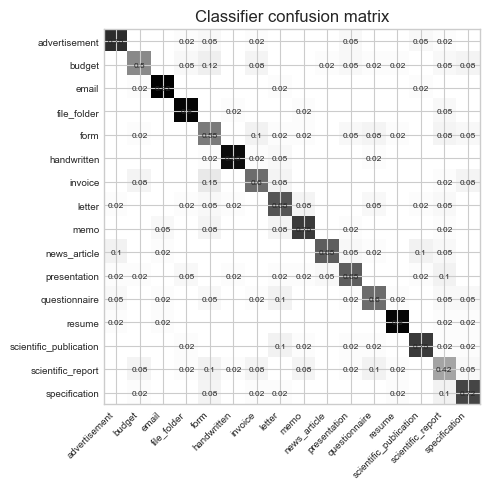

In [10]:
# Итоговый отчёт по классификатору
finetuned_classifier.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for images, labels in test_loader:
        logits = finetuned_classifier(images.to(device))
        preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()
        all_preds.extend(preds)
        all_targets.extend(labels.numpy().tolist())

print(classification_report(all_targets, all_preds, target_names=class_names, zero_division=0))
plot_confusion_matrix(
    all_targets,
    all_preds,
    class_names,
    title="Classifier confusion matrix",
    save_path=classifier_out_dir / "confusion_matrix.png",
)

## 2. OCR / text recognition на FUNSD

В этой части:
- на training/validation/test OCR работает на word-level кропах из FUNSD;
- baseline считается через Tesseract;
- inference для примеров из `samples` теперь сделан правильно: сначала идёт детекция текстовых областей на странице, затем распознавание каждого кропа и сборка итогового текста.

Именно это убирает ситуацию, когда TrOCR получает целую страницу и начинает «зацикливаться» на коротких фрагментах.


In [11]:
def iter_funsd_docs(split_dir: Path):
    split_dir = Path(split_dir)
    img_dir = split_dir / "images"
    ann_dir = split_dir / "annotations"

    if not img_dir.exists() or not ann_dir.exists():
        raise FileNotFoundError(
            f"Не найдены images/annotations в {split_dir}. "
            f"Ожидается стандартная структура FUNSD."
        )

    ann_files = sorted(ann_dir.glob("*.json"))
    for ann_path in ann_files:
        doc_id = ann_path.stem
        image_path = img_dir / f"{doc_id}.png"
        if not image_path.exists():
            candidates = list(img_dir.glob(f"{doc_id}.*"))
            image_path = candidates[0] if candidates else None
        if image_path is None or not Path(image_path).exists():
            continue

        with open(ann_path, "r", encoding="utf-8") as f:
            ann = json.load(f)

        yield doc_id, Path(image_path), ann

def extract_ocr_samples_from_funsd(split_dir: str, crop_pad: int = 2, min_word_len: int = 1):
    split_dir = Path(split_dir)
    samples = []

    docs = list(iter_funsd_docs(split_dir))
    for doc_id, image_path, ann in tqdm(docs, desc=f"Parsing {split_dir.name}"):
        img = safe_open_image(image_path)
        width, height = img.size

        for item in ann.get("form", []):
            words = item.get("words")
            if words and isinstance(words, list):
                for word in words:
                    text = normalize_text(word.get("text", ""))
                    box = word.get("box")
                    if not text or len(text) < min_word_len or not box or len(box) != 4:
                        continue

                    x0, y0, x1, y1 = box
                    x0 = max(0, int(x0) - crop_pad)
                    y0 = max(0, int(y0) - crop_pad)
                    x1 = min(width, int(x1) + crop_pad)
                    y1 = min(height, int(y1) + crop_pad)

                    if x1 <= x0 or y1 <= y0:
                        continue

                    crop = img.crop((x0, y0, x1, y1)).convert("RGB")
                    samples.append({"doc_id": doc_id, "image": crop, "text": text})
                continue

            text = normalize_text(item.get("text", ""))
            box = item.get("box") or item.get("bbox")
            if not text or len(text) < min_word_len or not box or len(box) != 4:
                continue

            x0, y0, x1, y1 = box
            x0 = max(0, int(x0) - crop_pad)
            y0 = max(0, int(y0) - crop_pad)
            x1 = min(width, int(x1) + crop_pad)
            y1 = min(height, int(y1) + crop_pad)

            if x1 <= x0 or y1 <= y0:
                continue

            crop = img.crop((x0, y0, x1, y1)).convert("RGB")
            samples.append({"doc_id": doc_id, "image": crop, "text": text})

    return samples

def split_grouped_samples(samples: List[dict], val_size=0.1, seed=42):
    doc_ids = sorted({s["doc_id"] for s in samples})
    if len(doc_ids) < 3:
        raise ValueError("Слишком мало документов для корректного split.")

    train_docs, val_docs = train_test_split(doc_ids, test_size=val_size, random_state=seed)
    train = [s for s in samples if s["doc_id"] in set(train_docs)]
    val = [s for s in samples if s["doc_id"] in set(val_docs)]
    return train, val

funsd_train_dir = Path(config.funsd_root) / "training_data"
funsd_test_dir = Path(config.funsd_root) / "testing_data"

train_ocr_samples = extract_ocr_samples_from_funsd(
    funsd_train_dir,
    crop_pad=config.ocr_crop_pad,
    min_word_len=config.ocr_min_word_len,
)
test_ocr_samples = extract_ocr_samples_from_funsd(
    funsd_test_dir,
    crop_pad=config.ocr_crop_pad,
    min_word_len=config.ocr_min_word_len,
)

ocr_train_samples, ocr_val_samples = split_grouped_samples(
    train_ocr_samples,
    val_size=config.val_size,
    seed=42,
)

if config.ocr_max_train_samples is not None and len(ocr_train_samples) > config.ocr_max_train_samples:
    random.shuffle(ocr_train_samples)
    ocr_train_samples = ocr_train_samples[: config.ocr_max_train_samples]

print(
    f"OCR samples: train={len(ocr_train_samples)}, "
    f"val={len(ocr_val_samples)}, test={len(test_ocr_samples)}"
)

Parsing testing_data: 100%|██████████| 50/50 [00:00<00:00, 59.60it/s]

OCR samples: train=2000, val=2323, test=8707


In [ ]:
class OCRWordDataset(Dataset):
    def __init__(self, samples: List[dict], processor: TrOCRProcessor, max_target_length: int = 32):
        self.samples = samples
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = sample["image"]
        text = normalize_text(sample["text"])

        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_target_length,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels, "text": text}

def ocr_collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.stack([item["labels"] for item in batch])
    texts = [item["text"] for item in batch]
    return {"pixel_values": pixel_values, "labels": labels, "texts": texts}

def build_ocr_loaders(train_samples, val_samples, test_samples, processor):
    if len(train_samples) == 0 or len(val_samples) == 0 or len(test_samples) == 0:
        raise ValueError(
            f"Пустая OCR-выборка: train={len(train_samples)}, val={len(val_samples)}, test={len(test_samples)}"
        )

    train_ds = OCRWordDataset(train_samples, processor, max_target_length=config.ocr_max_target_length)
    val_ds = OCRWordDataset(val_samples, processor, max_target_length=config.ocr_max_target_length)
    test_ds = OCRWordDataset(test_samples, processor, max_target_length=config.ocr_max_target_length)

    train_loader = DataLoader(
        train_ds,
        batch_size=config.ocr_batch_size,
        shuffle=True,
        num_workers=0,
        collate_fn=ocr_collate_fn,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=config.ocr_batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=ocr_collate_fn,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=config.ocr_batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=ocr_collate_fn,
    )
    return train_loader, val_loader, test_loader

def decode_label_batch(labels, processor):
    labels = labels.clone()
    labels[labels == -100] = processor.tokenizer.pad_token_id
    return processor.batch_decode(labels, skip_special_tokens=True)

def evaluate_ocr(model, processor, loader, max_length=32, desc="OCR eval"):
    if len(loader) == 0:
        raise ValueError("Пустой DataLoader в evaluate_ocr.")

    model.eval()
    losses = []
    preds, refs = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values, labels=labels)
            losses.append(outputs.loss.item())

            generated_ids = model.generate(
                pixel_values,
                max_length=max_length,
                num_beams=config.ocr_num_beams,
            )

            batch_preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
            batch_refs = decode_label_batch(labels.cpu(), processor)

            preds.extend([normalize_text(x) for x in batch_preds])
            refs.extend([normalize_text(x) for x in batch_refs])

    cer = float(np.mean([compute_cer(p, r) for p, r in zip(preds, refs)])) if refs else 0.0
    wer = float(np.mean([compute_wer(p, r) for p, r in zip(preds, refs)])) if refs else 0.0
    exact_match = float(np.mean([p == r for p, r in zip(preds, refs)])) if refs else 0.0

    return {
        "loss": float(np.mean(losses)) if losses else 0.0,
        "cer": cer,
        "wer": wer,
        "exact_match": exact_match,
    }

def train_ocr(model, processor, train_loader, val_loader, epochs=2, lr=1e-5, save_dir: Optional[Path] = None):
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    best_state = None
    best_cer = float("inf")
    best_epoch = 0
    history = []

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        best_path = save_dir / "ocr_best.pt"
    else:
        best_path = None

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        optimizer.zero_grad(set_to_none=True)

        for step, batch in enumerate(tqdm(train_loader, desc=f"OCR epoch {epoch}/{epochs}"), start=1):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                outputs = model(pixel_values=pixel_values, labels=labels)
                loss = outputs.loss / config.grad_accum_steps

            scaler.scale(loss).backward()
            train_losses.append(loss.item() * config.grad_accum_steps)

            if step % config.grad_accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

        if len(train_loader) % config.grad_accum_steps != 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        train_loss = float(np.mean(train_losses)) if train_losses else 0.0
        val_metrics = evaluate_ocr(
            model,
            processor,
            val_loader,
            max_length=config.ocr_max_target_length,
            desc=f"OCR val epoch {epoch}/{epochs}",
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        })

        print(
            f"OCR | epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_cer={val_metrics['cer']:.4f} | "
            f"val_wer={val_metrics['wer']:.4f} | "
            f"val_exact={val_metrics['exact_match']:.4f}"
        )

        if val_metrics["cer"] < best_cer:
            best_cer = val_metrics["cer"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            if best_path is not None:
                torch.save(best_state, best_path)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

Loading weights: 100%|██████████| 478/478 [00:00<00:00, 3607.66it/s]
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
OCR val epoch 1/5: 100%|██████████| 1162/1162 [06:22<00:00,  3.04it/s]


OCR | epoch 1/5 | train_loss=0.6643 | val_cer=0.0798 | val_wer=0.1774 | val_exact=0.8235


OCR val epoch 2/5: 100%|██████████| 1162/1162 [06:02<00:00,  3.21it/s]


OCR | epoch 2/5 | train_loss=0.1791 | val_cer=0.0676 | val_wer=0.1580 | val_exact=0.8416


OCR val epoch 3/5: 100%|██████████| 1162/1162 [05:34<00:00,  3.47it/s]


...

OCR val epoch 4/5: 100%|██████████| 1162/1162 [05:27<00:00,  3.55it/s]


OCR | epoch 4/5 | train_loss=0.0819 | val_cer=0.0656 | val_wer=0.1728 | val_exact=0.8261


OCR val epoch 5/5: 100%|██████████| 1162/1162 [05:26<00:00,  3.56it/s]


OCR | epoch 5/5 | train_loss=0.0448 | val_cer=0.0690 | val_wer=0.1681 | val_exact=0.8325


OCR finetuned test: 100%|██████████| 4354/4354 [20:29<00:00,  3.54it/s]


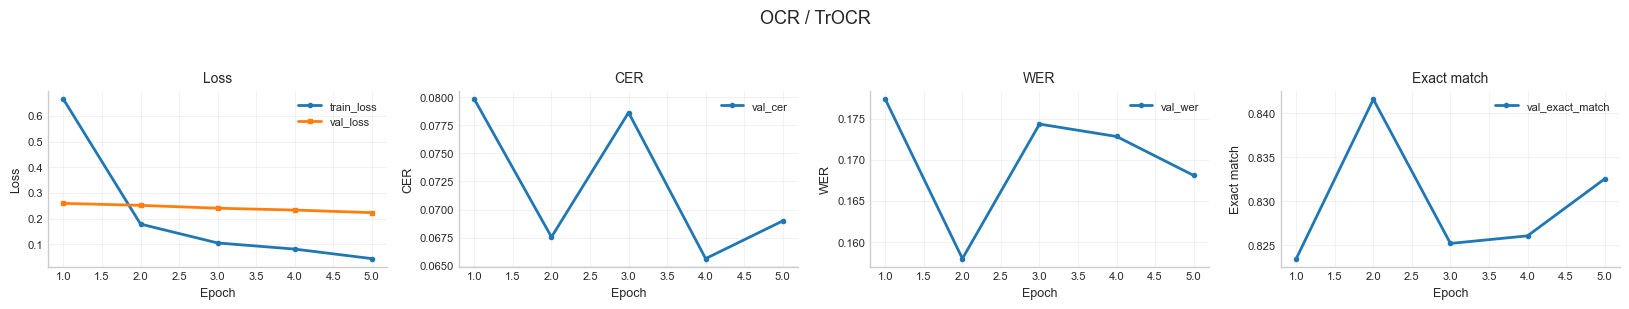

OCR baseline validation: {'loss': 12.439539294234653, 'cer': 0.43281064131257846, 'wer': 0.5542402066293586, 'exact_match': 0.4511407662505381}
OCR baseline test: {'loss': 12.578094262292641, 'cer': 0.5220584100895093, 'wer': 0.6268423873511734, 'exact_match': 0.3889973584472264}
OCR fine-tuned validation: {'loss': 0.23360079012983828, 'cer': 0.06564610354967651, 'wer': 0.17283684890228154, 'exact_match': 0.8260869565217391}
OCR fine-tuned test: {'loss': 0.30601883787976386, 'cer': 0.08610248462026737, 'wer': 0.20977374526243253, 'exact_match': 0.7928103824509015}


In [13]:
processor = TrOCRProcessor.from_pretrained(config.ocr_model_name)
ocr_model = VisionEncoderDecoderModel.from_pretrained(config.ocr_model_name)

pad_token_id = processor.tokenizer.pad_token_id
decoder_start_token_id = (
    processor.tokenizer.bos_token_id
    if processor.tokenizer.bos_token_id is not None
    else processor.tokenizer.cls_token_id
)
eos_token_id = processor.tokenizer.eos_token_id
if eos_token_id is None:
    eos_token_id = processor.tokenizer.sep_token_id

ocr_model.config.pad_token_id = pad_token_id
ocr_model.config.decoder_start_token_id = decoder_start_token_id
ocr_model.config.eos_token_id = eos_token_id
ocr_model.config.vocab_size = ocr_model.config.decoder.vocab_size
ocr_model.config.use_cache = False

if config.freeze_ocr_encoder:
    for param in ocr_model.encoder.parameters():
        param.requires_grad = False

ocr_model.to(device)

ocr_train_loader, ocr_val_loader, ocr_test_loader = build_ocr_loaders(
    ocr_train_samples, ocr_val_samples, test_ocr_samples, processor
)

ocr_baseline_val = evaluate_ocr(
    ocr_model,
    processor,
    ocr_val_loader,
    max_length=config.ocr_max_target_length,
    desc="OCR baseline val",
)
ocr_baseline_test = evaluate_ocr(
    ocr_model,
    processor,
    ocr_test_loader,
    max_length=config.ocr_max_target_length,
    desc="OCR baseline test",
)

ocr_out_dir = Path(config.output_dir) / "ocr_trocr_funsd"
ocr_out_dir.mkdir(parents=True, exist_ok=True)

ocr_model, ocr_history = train_ocr(
    ocr_model,
    processor,
    ocr_train_loader,
    ocr_val_loader,
    epochs=config.ocr_epochs,
    lr=config.ocr_lr,
    save_dir=ocr_out_dir,
)

ocr_finetuned_val = evaluate_ocr(
    ocr_model,
    processor,
    ocr_val_loader,
    max_length=config.ocr_max_target_length,
    desc="OCR finetuned val",
)
ocr_finetuned_test = evaluate_ocr(
    ocr_model,
    processor,
    ocr_test_loader,
    max_length=config.ocr_max_target_length,
    desc="OCR finetuned test",
)

plot_history(
    ocr_history,
    "OCR / TrOCR",
    [
        ("train_loss", "val_loss", "Loss"),
        ("val_cer", None, "CER"),
        ("val_wer", None, "WER"),
        ("val_exact_match", None, "Exact match"),
    ],
    save_path=ocr_out_dir / "ocr_curves.png",
)

torch.save(ocr_model.state_dict(), ocr_out_dir / "ocr_final.pt")
processor.save_pretrained(ocr_out_dir)
ocr_history.to_csv(ocr_out_dir / "history.csv", index=False)

print("OCR baseline validation:", ocr_baseline_val)
print("OCR baseline test:", ocr_baseline_test)
print("OCR fine-tuned validation:", ocr_finetuned_val)
print("OCR fine-tuned test:", ocr_finetuned_test)

### OCR baseline: Tesseract

Ниже считается baseline для OCR на тех же FUNSD-кропах, которые используются в основном эксперименте.  
Это делает сравнение честным: baseline и fine-tuned модель оцениваются на одном и том же test-set.


In [14]:

def evaluate_tesseract_ocr(samples, lang: str = "eng", desc: str = "Tesseract baseline"):
    preds = []
    refs = []

    for sample in tqdm(samples, desc=desc):
        image = sample["image"]
        ref = normalize_text(sample["text"])

        # Tesseract works best on grayscale / RGB to simplify.
        img = image.convert("RGB")
        pred = pytesseract.image_to_string(img, lang=lang)

        pred = normalize_text(pred)
        preds.append(pred)
        refs.append(ref)

    cer_values = [compute_cer(p, r) for p, r in zip(preds, refs)]
    wer_values = [compute_wer(p, r) for p, r in zip(preds, refs)]

    metrics = {
        "loss": np.nan,  # у Tesseract нет loss в стиле нейросети
        "cer": float(np.mean(cer_values)) if cer_values else np.nan,
        "wer": float(np.mean(wer_values)) if wer_values else np.nan,
        "exact_match": float(np.mean([p == r for p, r in zip(preds, refs)])) if refs else np.nan,
        "n_samples": len(refs),
    }
    return metrics

# OCR_BASELINE_MAX_SAMPLES = 250
OCR_BASELINE_MAX_SAMPLES = None

baseline_ocr_eval_samples = test_ocr_samples if OCR_BASELINE_MAX_SAMPLES is None else test_ocr_samples[:OCR_BASELINE_MAX_SAMPLES]
ocr_tesseract_baseline_val = evaluate_tesseract_ocr(
    ocr_val_samples if OCR_BASELINE_MAX_SAMPLES is None else ocr_val_samples[:OCR_BASELINE_MAX_SAMPLES],
    lang="eng",
    desc="Tesseract val",
)
ocr_tesseract_baseline_test = evaluate_tesseract_ocr(
    baseline_ocr_eval_samples,
    lang="eng",
    desc="Tesseract test",
)

print("Tesseract baseline val:", ocr_tesseract_baseline_val)
print("Tesseract baseline test:", ocr_tesseract_baseline_test)


Tesseract test: 100%|██████████| 8707/8707 [20:06<00:00,  7.22it/s]


Tesseract baseline val: {'loss': nan, 'cer': 0.4772313345763626, 'wer': 0.5505811450710288, 'exact_match': 0.4537236332328885, 'n_samples': 2323}
Tesseract baseline test: {'loss': nan, 'cer': 0.5957045028654079, 'wer': 0.7046629148960606, 'exact_match': 0.30446766969105316, 'n_samples': 8707}


## 3. Сравнение результатов

Классификация и OCR — это разные задачи, поэтому сравнение лучше делать **отдельно**.

=== Classification ===


,Model,Accuracy,Macro F1,Loss
0,Frozen ResNet18,0.437500,0.430645,1.931039
1,Fine-tuned ResNet18,0.703125,0.704221,1.069412


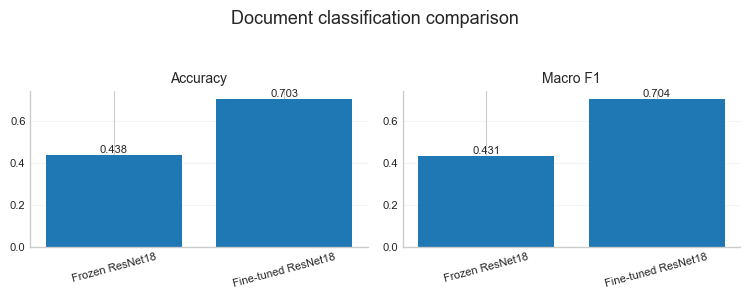

=== OCR ===


,Model,CER,WER,Exact match,Loss
0,Tesseract baseline,0.595705,0.704663,0.304468,NaN
1,Fine-tuned TrOCR,0.086102,0.209774,0.792810,0.306019


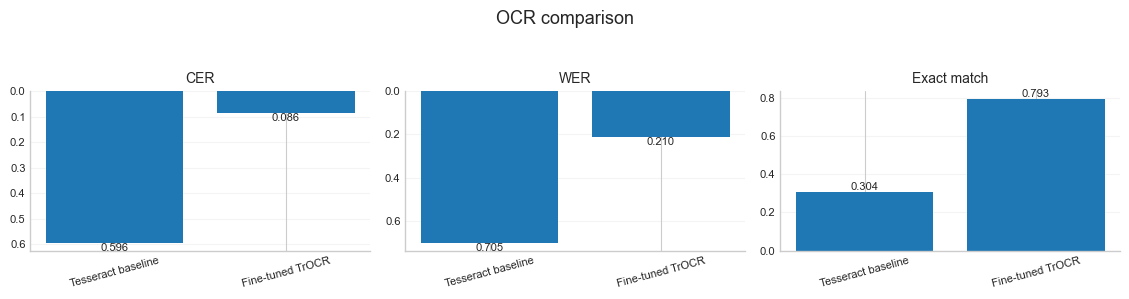

In [15]:

classification_compare = pd.DataFrame([
    {
        "Model": "Frozen ResNet18",
        "Accuracy": baseline_test_metrics["accuracy"],
        "Macro F1": baseline_test_metrics["macro_f1"],
        "Loss": baseline_test_metrics["loss"],
    },
    {
        "Model": "Fine-tuned ResNet18",
        "Accuracy": finetuned_test_metrics["accuracy"],
        "Macro F1": finetuned_test_metrics["macro_f1"],
        "Loss": finetuned_test_metrics["loss"],
    },
])

ocr_compare = pd.DataFrame([
    {
        "Model": "Tesseract baseline",
        "CER": ocr_tesseract_baseline_test["cer"],
        "WER": ocr_tesseract_baseline_test["wer"],
        "Exact match": ocr_tesseract_baseline_test["exact_match"],
        "Loss": ocr_tesseract_baseline_test["loss"],
    },
    {
        "Model": "Fine-tuned TrOCR",
        "CER": ocr_finetuned_test["cer"],
        "WER": ocr_finetuned_test["wer"],
        "Exact match": ocr_finetuned_test["exact_match"],
        "Loss": ocr_finetuned_test["loss"],
    },
])

print("=== Classification ===")
display(classification_compare)

plot_comparison_bars(
    classification_compare,
    "Document classification comparison",
    ["Accuracy", "Macro F1"],
    save_path=Path(config.output_dir) / "classifier_resnet18" / "comparison_bars.png",
)

print("=== OCR ===")
display(ocr_compare)

plot_comparison_bars(
    ocr_compare,
    "OCR comparison",
    ["CER", "WER", "Exact match"],
    save_path=Path(config.output_dir) / "ocr_trocr_funsd" / "comparison_bars.png",
    invert_metrics={"CER", "WER"},
)


## 4. Эксперименты, сводка и финальный вывод

В этой секции собраны результаты экспериментов в формате, удобном для отчёта ЛР3:
- baseline vs fine-tuned для классификатора;
- baseline vs fine-tuned для OCR;
- история обучения по эпохам;
- краткий вывод по финальной модели и её компромиссам.


,Task,Experiment,Best epoch,Val metric,Test metric,Notes
0,Classification,Frozen ResNet18,8,0.4945,0.4306,baseline
1,Classification,Fine-tuned ResNet18,6,0.7629,0.7042,лучший результат у fine-tune
2,OCR,Tesseract baseline,n/a,0.4772,0.5957,baseline для OCR
3,OCR,Fine-tuned TrOCR,4,0.0656,0.0861,лучший результат на FUNSD


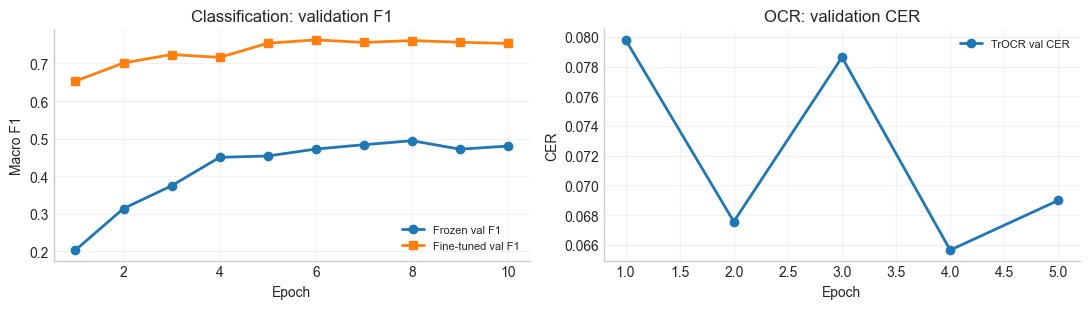

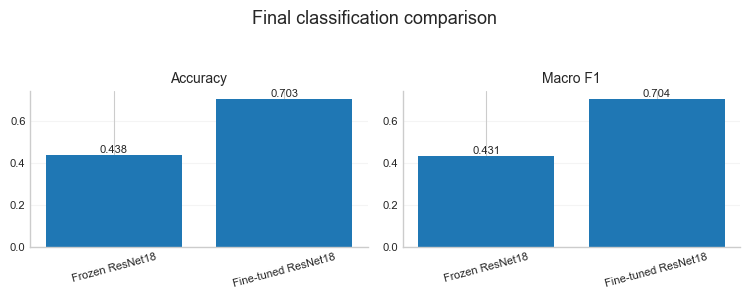

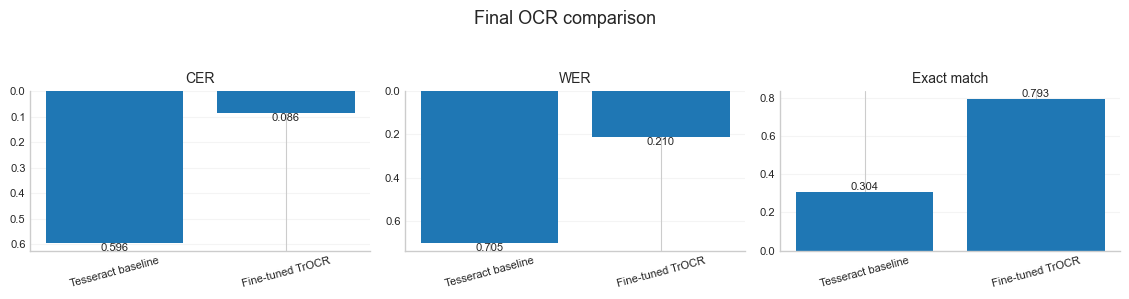

Classifier best val F1: 0.7629
Classifier test F1: 0.7042
OCR baseline test CER: 0.5957
OCR fine-tuned test CER: 0.0861
OCR best val CER: 0.0656


In [ ]:

def load_history_df(var_name: str, fallback_paths: List[str]) -> pd.DataFrame:
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
        return globals()[var_name].copy()
    for p in fallback_paths:
        path = Path(p)
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError(f"Не удалось загрузить историю {var_name}. Проверены пути: {fallback_paths}")

baseline_hist = load_history_df(
    "baseline_history",
    [
        "baseline_history.csv",
        str(Path(config.output_dir) / "classifier_resnet18" / "baseline_history.csv"),
    ],
)
finetuned_hist = load_history_df(
    "finetuned_history",
    [
        "finetuned_history.csv",
        str(Path(config.output_dir) / "classifier_resnet18" / "finetuned_history.csv"),
    ],
)
ocr_hist = load_history_df(
    "ocr_history",
    [
        "history.csv",
        str(Path(config.output_dir) / "ocr_trocr_funsd" / "history.csv"),
    ],
)

def best_row_cls(df: pd.DataFrame) -> pd.Series:
    return df.loc[df["val_macro_f1"].idxmax()]

def best_row_ocr(df: pd.DataFrame) -> pd.Series:
    return df.loc[df["val_cer"].idxmin()]

report_rows = pd.DataFrame([
    {
        "Task": "Classification",
        "Experiment": "Frozen ResNet18",
        "Best epoch": int(best_row_cls(baseline_hist)["epoch"]),
        "Val metric": round(float(best_row_cls(baseline_hist)["val_macro_f1"]), 4),
        "Test metric": round(float(baseline_test_metrics["macro_f1"]), 4),
        "Notes": "baseline",
    },
    {
        "Task": "Classification",
        "Experiment": "Fine-tuned ResNet18",
        "Best epoch": int(best_row_cls(finetuned_hist)["epoch"]),
        "Val metric": round(float(best_row_cls(finetuned_hist)["val_macro_f1"]), 4),
        "Test metric": round(float(finetuned_test_metrics["macro_f1"]), 4),
        "Notes": "лучший результат у fine-tune",
    },
    {
        "Task": "OCR",
        "Experiment": "Tesseract baseline",
        "Best epoch": "n/a",
        "Val metric": round(float(ocr_tesseract_baseline_val["cer"]), 4),
        "Test metric": round(float(ocr_tesseract_baseline_test["cer"]), 4),
        "Notes": "baseline для OCR",
    },
    {
        "Task": "OCR",
        "Experiment": "Fine-tuned TrOCR",
        "Best epoch": int(best_row_ocr(ocr_hist)["epoch"]),
        "Val metric": round(float(best_row_ocr(ocr_hist)["val_cer"]), 4),
        "Test metric": round(float(ocr_finetuned_test["cer"]), 4),
        "Notes": "лучший результат на FUNSD",
    },
])

display(report_rows)

# Компактные кривые обучения
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

axes[0].plot(baseline_hist["epoch"], baseline_hist["val_macro_f1"], marker="o", linewidth=2, label="Frozen val F1")
axes[0].plot(finetuned_hist["epoch"], finetuned_hist["val_macro_f1"], marker="s", linewidth=2, label="Fine-tuned val F1")
axes[0].set_title("Classification: validation F1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Macro F1")
axes[0].grid(True, alpha=0.25)
axes[0].legend(frameon=False, fontsize=8)
for spine in ["top", "right"]:
    axes[0].spines[spine].set_visible(False)

axes[1].plot(ocr_hist["epoch"], ocr_hist["val_cer"], marker="o", linewidth=2, label="TrOCR val CER")
axes[1].set_title("OCR: validation CER")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("CER")
axes[1].grid(True, alpha=0.25)
axes[1].legend(frameon=False, fontsize=8)
for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

final_compare_cls = pd.DataFrame([
    {"Model": "Frozen ResNet18", "Accuracy": baseline_test_metrics["accuracy"], "Macro F1": baseline_test_metrics["macro_f1"]},
    {"Model": "Fine-tuned ResNet18", "Accuracy": finetuned_test_metrics["accuracy"], "Macro F1": finetuned_test_metrics["macro_f1"]},
])
plot_comparison_bars(final_compare_cls, "Final classification comparison", ["Accuracy", "Macro F1"], invert_metrics=set())

final_compare_ocr = pd.DataFrame([
    {"Model": "Tesseract baseline", "CER": ocr_tesseract_baseline_test["cer"], "WER": ocr_tesseract_baseline_test["wer"], "Exact match": ocr_tesseract_baseline_test["exact_match"]},
    {"Model": "Fine-tuned TrOCR", "CER": ocr_finetuned_test["cer"], "WER": ocr_finetuned_test["wer"], "Exact match": ocr_finetuned_test["exact_match"]},
])
plot_comparison_bars(final_compare_ocr, "Final OCR comparison", ["CER", "WER", "Exact match"], invert_metrics={"CER", "WER"})

print("Classifier best val F1:", round(float(best_row_cls(finetuned_hist)["val_macro_f1"]), 4))
print("Classifier test F1:", round(float(finetuned_test_metrics["macro_f1"]), 4))
print("OCR baseline test CER:", round(float(ocr_tesseract_baseline_test["cer"]), 4))
print("OCR fine-tuned test CER:", round(float(ocr_finetuned_test["cer"]), 4))
print("OCR best val CER:", round(float(best_row_ocr(ocr_hist)["val_cer"]), 4))


In [ ]:

# Инференс: загрузка моделей + детекция текста + OCR по всей странице
from pathlib import Path
from typing import List, Dict, Any, Tuple, Optional
from dataclasses import dataclass
import json
import math
import os
import re
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pytesseract
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from IPython.display import display

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "Config" not in globals():
    @dataclass
    class Config:
        rvl_cdip_root: str = "datasets/rvl-cdip-small-200"
        funsd_root: str = "datasets/FUNSD"
        output_dir: str = "outputs"

        classifier_img_size: int = 224
        classifier_batch_size: int = 16 if torch.cuda.is_available() else 8

        ocr_model_name: str = "microsoft/trocr-base-printed"
        ocr_batch_size: int = 2 if torch.cuda.is_available() else 1
        ocr_max_target_length: int = 32
        ocr_num_beams: int = 1

        ocr_page_lang: str = "eng"
        ocr_page_min_conf: int = 40
        ocr_page_min_box_size: int = 8
        ocr_page_max_words: int = 500
        ocr_page_pad: int = 4
        ocr_page_batch_size: int = 8

    config = Config()
else:
    if "config" not in globals():
        config = Config()

Path(config.output_dir).mkdir(parents=True, exist_ok=True)

# ---------- Утилиты ----------
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def ensure_image(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in IMG_EXTS

def normalize_text(text: Optional[str]) -> str:
    if text is None:
        return ""
    text = str(text)
    text = text.replace("\x00", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def safe_open_image(path: Path) -> Image.Image:
    img = Image.open(path).convert("RGB")
    return img

# Классификатор
class DocumentClassifier(nn.Module):
    def __init__(self, num_classes: int, freeze_backbone: bool = True):
        super().__init__()
        backbone = torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.classifier = nn.Linear(in_features, num_classes)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):
        feats = self.backbone(x)
        return self.classifier(feats)

eval_transform = transforms.Compose([
    transforms.Resize((config.classifier_img_size, config.classifier_img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def get_image_files(root: Path) -> List[Path]:
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"Не найден каталог: {root.resolve()}")
    files = [p for p in root.rglob("*") if ensure_image(p)]
    return sorted(files)

# Загрузка моделей

def _extract_state_dict(ckpt: Any) -> Dict[str, Any]:
    """
    Unwrap common checkpoint formats and return the actual parameter dict.
    Supports plain state_dicts as well as dicts with keys like
    'state_dict' or 'model_state_dict'.
    """
    if isinstance(ckpt, dict):
        for key in ("state_dict", "model_state_dict", "model", "net"):
            if key in ckpt and isinstance(ckpt[key], dict):
                ckpt = ckpt[key]
                break
    if not isinstance(ckpt, dict):
        raise TypeError(f"Unsupported checkpoint type: {type(ckpt)!r}")
    return ckpt


def _strip_module_prefix(state_dict: Dict[str, Any]) -> Dict[str, Any]:
    # Remove DataParallel / DDP prefix if present.
    if any(k.startswith("module.") for k in state_dict.keys()):
        return {k.replace("module.", "", 1): v for k, v in state_dict.items()}
    return state_dict


def _remap_linear_head_keys(
    state_dict: Dict[str, Any],
    model: nn.Module,
) -> Dict[str, Any]:
    """
    Make classifier head keys compatible across older notebook versions.
    Handles:
      - head.*  <-> classifier.*
      - module.head.* / module.classifier.*
    """
    model_keys = list(model.state_dict().keys())
    model_has_head = any(k.startswith("head.") for k in model_keys)
    model_has_classifier = any(k.startswith("classifier.") for k in model_keys)

    ckpt_has_head = any(k.startswith("head.") for k in state_dict.keys())
    ckpt_has_classifier = any(k.startswith("classifier.") for k in state_dict.keys())

    remapped = dict(state_dict)

    if model_has_classifier and ckpt_has_head and not ckpt_has_classifier:
        remapped = {
            (k.replace("head.", "classifier.", 1) if k.startswith("head.") else k): v
            for k, v in remapped.items()
        }
    elif model_has_head and ckpt_has_classifier and not ckpt_has_head:
        remapped = {
            (k.replace("classifier.", "head.", 1) if k.startswith("classifier.") else k): v
            for k, v in remapped.items()
        }

    return remapped


def load_with_flexible_head(model: nn.Module, ckpt: Any) -> nn.Module:
    state_dict = _extract_state_dict(ckpt)
    state_dict = _strip_module_prefix(state_dict)
    state_dict = _remap_linear_head_keys(state_dict, model)

    missing, unexpected = model.load_state_dict(state_dict, strict=False)

    if missing or unexpected:
        main_missing = [k for k in missing if not k.startswith(("backbone.", "head.", "classifier."))]
        main_unexpected = [k for k in unexpected if not k.startswith(("backbone.", "head.", "classifier."))]
        if main_missing or main_unexpected:
            raise RuntimeError(
                "Не удалось корректно загрузить веса.\n"
                f"Missing keys: {missing}\n"
                f"Unexpected keys: {unexpected}"
            )
    return model



def load_classifier_for_inference():
    global class_names
    cls_dir = Path(config.output_dir) / "classifier_resnet18"
    class_names_path = cls_dir / "class_names.json"
    weights_path = cls_dir / "classifier_finetuned_best.pt"

    if not class_names_path.exists():
        raise FileNotFoundError(f"Не найден файл с классами: {class_names_path}")
    if not weights_path.exists():
        raise FileNotFoundError(f"Не найден файл весов классификатора: {weights_path}")

    with open(class_names_path, "r", encoding="utf-8") as f:
        names = json.load(f)

    model = DocumentClassifier(num_classes=len(names), freeze_backbone=False).to(device)
    checkpoint = torch.load(weights_path, map_location=device)
    model = load_with_flexible_head(model, checkpoint)
    model.eval()
    class_names = names
    return model, names


def load_ocr_for_inference():
    ocr_dir = Path(config.output_dir) / "ocr_trocr_funsd"
    weights_path = ocr_dir / "ocr_best.pt"

    if not weights_path.exists():
        raise FileNotFoundError(f"Не найден файл весов OCR-модели: {weights_path}")

    # processor можно брать из базовой модели; веса — из fine-tuned чекпоинта
    proc = TrOCRProcessor.from_pretrained(config.ocr_model_name)
    model = VisionEncoderDecoderModel.from_pretrained(config.ocr_model_name)

    pad_token_id = proc.tokenizer.pad_token_id
    decoder_start_token_id = (
        proc.tokenizer.bos_token_id
        if proc.tokenizer.bos_token_id is not None
        else proc.tokenizer.cls_token_id
    )
    eos_token_id = proc.tokenizer.eos_token_id
    if eos_token_id is None:
        eos_token_id = proc.tokenizer.sep_token_id

    model.config.pad_token_id = pad_token_id
    model.config.decoder_start_token_id = decoder_start_token_id
    model.config.eos_token_id = eos_token_id
    model.config.vocab_size = model.config.decoder.vocab_size
    model.config.use_cache = False

    checkpoint = torch.load(weights_path, map_location=device)
    state_dict = _extract_state_dict(checkpoint)
    state_dict = _strip_module_prefix(state_dict)
    model.load_state_dict(state_dict, strict=True)
    model = model.to(device)
    model.eval()
    return model, proc


# Full-page OCR
def detect_text_boxes_tesseract(
    image: Image.Image,
    lang: Optional[str] = None,
    min_conf: Optional[int] = None,
    min_box_size: Optional[int] = None,
    max_words: Optional[int] = None,
) -> List[Dict[str, Any]]:
    lang = lang or config.ocr_page_lang
    min_conf = config.ocr_page_min_conf if min_conf is None else min_conf
    min_box_size = config.ocr_page_min_box_size if min_box_size is None else min_box_size
    max_words = config.ocr_page_max_words if max_words is None else max_words

    data = pytesseract.image_to_data(image, lang=lang, output_type=pytesseract.Output.DICT)
    detections: List[Dict[str, Any]] = []

    for i in range(len(data["text"])):
        text = normalize_text(data["text"][i])
        if not text:
            continue

        try:
            conf = float(data["conf"][i])
        except Exception:
            conf = -1.0

        if conf < min_conf:
            continue

        x = int(data["left"][i])
        y = int(data["top"][i])
        w = int(data["width"][i])
        h = int(data["height"][i])

        if w < min_box_size or h < min_box_size:
            continue

        detections.append(
            {
                "x0": x,
                "y0": y,
                "x1": x + w,
                "y1": y + h,
                "text": text,
                "conf": conf,
                "block_num": int(data["block_num"][i]),
                "par_num": int(data["par_num"][i]),
                "line_num": int(data["line_num"][i]),
                "word_num": int(data["word_num"][i]),
            }
        )

    detections.sort(
        key=lambda d: (
            d["block_num"],
            d["par_num"],
            d["line_num"],
            d["y0"],
            d["x0"],
        )
    )
    if len(detections) > max_words:
        detections = detections[:max_words]
    return detections

def crop_with_padding(image: Image.Image, box: Tuple[int, int, int, int], pad: Optional[int] = None) -> Image.Image:
    pad = config.ocr_page_pad if pad is None else pad
    width, height = image.size
    x0, y0, x1, y1 = box
    x0 = max(0, int(x0) - pad)
    y0 = max(0, int(y0) - pad)
    x1 = min(width, int(x1) + pad)
    y1 = min(height, int(y1) + pad)
    if x1 <= x0 or y1 <= y0:
        return image.crop((0, 0, 1, 1)).convert("RGB")
    return image.crop((x0, y0, x1, y1)).convert("RGB")

def generate_text_for_crops(
    crops: List[Image.Image],
    model,
    proc,
    batch_size: Optional[int] = None,
    max_length: Optional[int] = None,
    num_beams: Optional[int] = None,
) -> List[str]:
    batch_size = config.ocr_page_batch_size if batch_size is None else batch_size
    max_length = config.ocr_max_target_length if max_length is None else max_length
    num_beams = config.ocr_num_beams if num_beams is None else num_beams

    preds: List[str] = []
    if len(crops) == 0:
        return preds

    for start in range(0, len(crops), batch_size):
        batch_crops = crops[start : start + batch_size]
        pixel_values = proc(images=batch_crops, return_tensors="pt").pixel_values.to(device)
        with torch.no_grad():
            generated_ids = model.generate(
                pixel_values,
                max_length=max_length,
                num_beams=num_beams,
            )
        batch_preds = proc.batch_decode(generated_ids, skip_special_tokens=True)
        preds.extend([normalize_text(p) for p in batch_preds])

    return preds

def ocr_full_page_with_detection(
    image: Image.Image,
    model,
    proc,
    lang: Optional[str] = None,
    min_conf: Optional[int] = None,
    min_box_size: Optional[int] = None,
    max_words: Optional[int] = None,
) -> Dict[str, Any]:
    detections = detect_text_boxes_tesseract(
        image,
        lang=lang,
        min_conf=min_conf,
        min_box_size=min_box_size,
        max_words=max_words,
    )

    if len(detections) == 0:
        fallback_text = normalize_text(pytesseract.image_to_string(image, lang=lang or config.ocr_page_lang))
        return {
            "full_text": fallback_text,
            "detections": [],
            "mode": "tesseract_full_page_fallback",
        }

    crops = [
        crop_with_padding(image, (d["x0"], d["y0"], d["x1"], d["y1"]), pad=config.ocr_page_pad)
        for d in detections
    ]
    pred_words = generate_text_for_crops(crops, model, proc)

    if len(pred_words) != len(detections):
        pred_words = (pred_words + [""] * len(detections))[: len(detections)]

    for det, pred in zip(detections, pred_words):
        det["ocr_text"] = pred

    line_groups: Dict[Tuple[int, int, int], List[Dict[str, Any]]] = {}
    for det in detections:
        key = (det["block_num"], det["par_num"], det["line_num"])
        line_groups.setdefault(key, []).append(det)

    ordered_lines = []
    for key in sorted(line_groups.keys()):
        line_items = sorted(line_groups[key], key=lambda d: (d["x0"], d["word_num"]))
        line_text = normalize_text(" ".join([d["ocr_text"] for d in line_items if d["ocr_text"]]))
        if line_text:
            ordered_lines.append(line_text)

    full_text = normalize_text("\n".join(ordered_lines))
    if not full_text:
        full_text = normalize_text(pytesseract.image_to_string(image, lang=lang or config.ocr_page_lang))

    return {
        "full_text": full_text,
        "detections": detections,
        "mode": "tesseract_detect_plus_trocr",
    }

# Инференс на папке samples
def predict_one_image(image_path: Path, clf_model, ocr_model, proc, names: List[str]):
    img = safe_open_image(image_path)

    clf_input = eval_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = clf_model(clf_input)
        probs = torch.softmax(logits, dim=1)[0]
        pred_idx = int(torch.argmax(probs).item())
        pred_class = names[pred_idx]
        confidence = float(probs[pred_idx].item())

    ocr_result = ocr_full_page_with_detection(
        img,
        ocr_model,
        proc,
        lang=config.ocr_page_lang,
        min_conf=config.ocr_page_min_conf,
        min_box_size=config.ocr_page_min_box_size,
        max_words=config.ocr_page_max_words,
    )

    return {
        "file": image_path.name,
        "path": str(image_path),
        "pred_class": pred_class,
        "confidence": confidence,
        "ocr_text": ocr_result["full_text"],
        "ocr_mode": ocr_result["mode"],
        "ocr_boxes": ocr_result["detections"],
        "image": img,
    }

samples_dir = Path("samples")
sample_files = get_image_files(samples_dir)

if len(sample_files) == 0:
    print(f"В папке {samples_dir.resolve()} не найдено изображений. Добавьте туда пару файлов и запустите ячейку ещё раз.")
else:
    clf_model, names = load_classifier_for_inference()
    ocr_model_inf, proc_inf = load_ocr_for_inference()

    results = [predict_one_image(p, clf_model, ocr_model_inf, proc_inf, names) for p in sample_files]
    results_df = pd.DataFrame([
        {
            "file": r["file"],
            "pred_class": r["pred_class"],
            "confidence": round(r["confidence"], 4),
            "ocr_mode": r["ocr_mode"],
            "ocr_text": r["ocr_text"],
            "n_boxes": len(r["ocr_boxes"]),
            "path": r["path"],
        }
        for r in results
    ])

    display(results_df[["file", "pred_class", "confidence", "ocr_mode", "n_boxes", "ocr_text"]])

    out_csv = Path(config.output_dir) / "samples_inference_results.csv"
    results_df.drop(columns=["path"]).to_csv(out_csv, index=False, encoding="utf-8-sig")
    print(f"Результаты сохранены в: {out_csv}")

    cols = 2
    rows = math.ceil(len(results) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
    axes = np.array(axes).reshape(-1) if len(results) > 1 else np.array([axes])

    for ax, res in zip(axes, results):
        ax.imshow(res["image"])
        ax.axis("off")
        preview = res["ocr_text"].replace("\n", " ")
        ax.set_title(
            f"{res['file']}\n"
            f"Class: {res['pred_class']} ({res['confidence']:.2f})\n"
            f"OCR: {preview[:80]}",
            fontsize=10,
        )

    for ax in axes[len(results):]:
        ax.axis("off")

    fig.tight_layout()
    plt.show()


In [18]:
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
